In [9]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import scipy.sparse as sp
import pywt
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

from helpers import *

import copy

In [2]:
%load_ext autoreload
%autoreload 2

In [26]:
# reconstruciton grid shape
H, W = 120, 40

# select samples to be used for normalization procedure
samples_idxs = np.arange(0,10000)
train_samples_path = Path(f"../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = np.array(train_samples_normalization)

# load forward model
A_path = Path("/home/fusiontomo/Repos/diffusion_tomography/forward_model/pilatus_geometry_matrix.npy")
#Path("forward_model/forward_model_sxr_full_geometry.npy")
A_tomo = np.load(A_path)
A_tomo_max = A_tomo.max()
A_tomo /= A_tomo_max

# compute y_tomo distribution
y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T


In [27]:
# define noise level 

sigma_noise = 0.05 * np.mean(y_tomo_train)
print(f"Noise level for normalized model: {sigma_noise:.4f}")

Noise level for normalized model: 0.3474


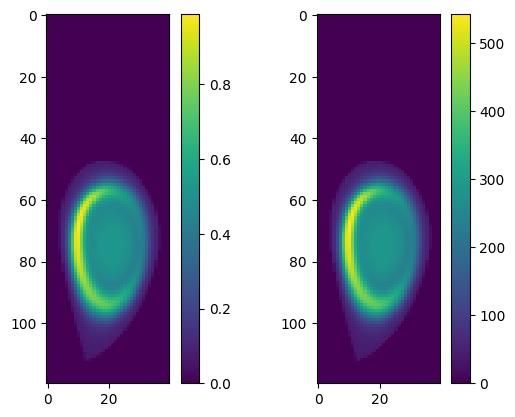

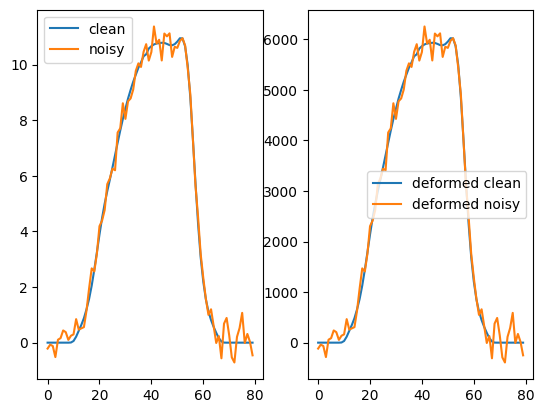

In [28]:
# load test samples
test_samples_path = Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy")
test_samples = np.load(test_samples_path)

# compute y_tomo distribution for test samples
y_tomo_test = test_samples.reshape(-1, H * W) @ A_tomo.T

np.random.seed(9901)
# compute noisy tomographic data
y_tomo_noisy = y_tomo_test + np.random.randn(*y_tomo_test.shape) * sigma_noise

# deform distribution
np.random.seed(0)
scaling_params_testset = (1 + np.random.rand(test_samples.shape[0], 1, 1) * 1000)
test_samples_deformed = test_samples * scaling_params_testset
y_tomo_noisy_deformed = y_tomo_noisy * scaling_params_testset.reshape(-1, 1)

# compute y_tomo deformed distribution for test samples
y_tomo_test_deformed = test_samples_deformed.reshape(-1, H * W) @ A_tomo.T

plt.Figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_samples[0,:])
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(test_samples_deformed[0,:])
plt.colorbar()
plt.show()


plt.Figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(y_tomo_test[0,:], label="clean")
plt.plot(y_tomo_noisy[0,:], label="noisy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(y_tomo_test_deformed[0,:], label="deformed clean")
plt.plot(y_tomo_noisy_deformed[0,:], label="deformed noisy")
plt.legend()
plt.show()


In [29]:
np.max(A_tomo)

np.float64(1.0)

MSE: 0.0019049100975634707


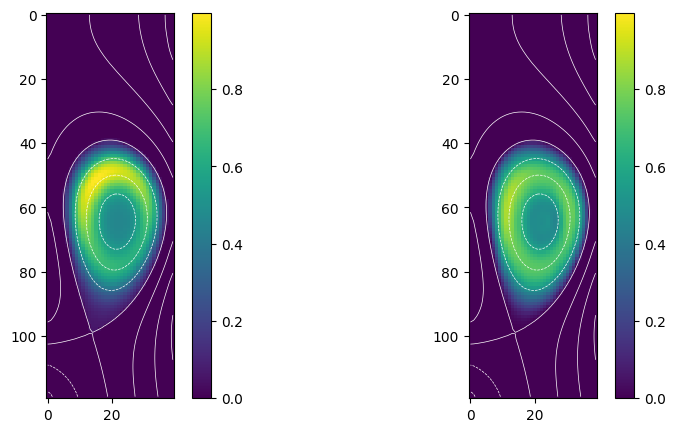

In [30]:
import copy
import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.hyperparameter_tuning as hyper_tune

sxr_samples = copy.deepcopy(test_samples)
samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
psis = np.load(os.path.join(samples_dir, 'psis_coarse.npy'))
alphas = np.load(os.path.join(samples_dir, 'alpha_random_values.npy'))
trim_val = np.load(os.path.join(samples_dir, 'trimming_values.npy'))


idx=12
reconstruction_shape = (120,40)
sigma_err = 0.25

reg_param=1e-1

ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
psi = psis[idx, :, :]
trim_val_ = trim_val[idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)

ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
psi = psis[idx, :, :]
trim_val_ = trim_val[idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)

f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=sp.csr_matrix(A_tomo),
                                                        sigma_err=0.25, reg_fct_type="anisotropic",
                                                        alpha=alphas[idx], plot=False,
                                                        seed=idx)
im_MAP = bcomp.compute_MAP(f, g, reg_param, with_pos_constraint=True, clipping_mask=mask_core, show_progress=False)



vmax=np.max([ground_truth.max(), im_MAP.max()])
fig, ax= plt.subplots(1, 2, figsize=(10, 5))
im=ax[0].imshow(ground_truth, vmax=vmax)
plt.colorbar(im,ax=ax[0])
ax[0].contour(psi, colors='w', linewidths=0.5)
im=ax[1].imshow(im_MAP, vmax=vmax)
plt.colorbar(im,ax=ax[1])
ax[1].contour(psi, colors='w', linewidths=0.5)

print("MSE:", np.mean((im_MAP - ground_truth)**2))

In [133]:
def estimate_noise_std(y):
    # Detail coefficients at finest scale
    d = pywt.wavedec(y, 'db1', level=1, mode='periodization')[1]
    # MAD estimator (robust to signal content)
    sigma = np.median(np.abs(d)) / 0.6745
    return sigma

def estimate_noise_std(y):
    # Detail coefficients at finest scale
    d = pywt.wavedec(y, 'db4', level=2, mode='periodization')
    d= d[-1]
    # keep only smallest xx% (tune this)
    thresh = np.percentile(np.abs(d), 80)
    d = d[np.abs(d) <= thresh]
    # MAD estimator (robust to signal content)
    sigma = np.median(np.abs(d)) / 0.6745
    return sigma


# def estimate_noise_std_patch(y, n_patches=5):
#     y = np.asarray(y).ravel()
#     N = len(y)
#     patch_size = N // n_patches

#     # truncate if not divisible (or handle remainder separately)
#     y = y[:patch_size * n_patches]

#     patches = y.reshape(n_patches, patch_size)

#     variances = np.var(patches, axis=1)

#     # take the smallest variances (noise-dominated patches)
#     k = max(1, n_patches // 2)  # e.g., keep half
#     sigma2 = np.mean(np.sort(variances)[:k])

#     return np.sqrt(sigma2)

# def estimate_noise_std_patch(y, patch_size=20, keep_ratio=0.2):
#     patches = np.lib.stride_tricks.sliding_window_view(y, patch_size)
#     variances = np.var(patches, axis=1)

#     # keep lowest-variance patches (least signal)
#     k = int(len(variances) * keep_ratio)
#     sigma2 = np.mean(np.sort(variances)[:k])

#     return np.sqrt(sigma2)

# def estimate_noise_std
# (y):
#     coeffs = pywt.wavedec(y, 'db1', level=2, mode='periodization')
#     d = coeffs[-1]  # finest scale
    
#     # Optional: trim extreme values (reduce signal leakage)
#     d = d[np.abs(d) < np.percentile(np.abs(d), 95)]
    
#     sigma = np.median(np.abs(d)) / 0.6745
#     return sigma

# def estimate_noise_std(y):
#     coeffs = pywt.wavedec(y, 'db1', level=2, mode='periodization')
#     d = coeffs[-1]  # finest scale
    
#     # Optional: trim extreme values (reduce signal leakage)
#     d = d[np.abs(d) < np.percentile(np.abs(d), 95)]
    
#     sigma = np.median(np.abs(d)) / 0.6745
#     return sigma

In [134]:
y = sigma_noise * np.random.randn(100)
print(estimate_noise_std(y))

0.17469274762894949


Computed normalization coefficient alpha: 919.0096
Estimated noise level: 0.185


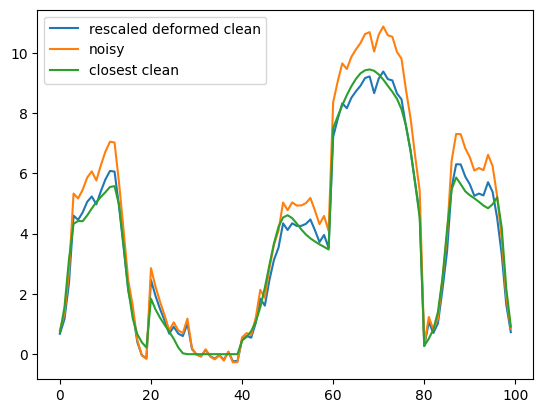

In [135]:
# estimate alpha scaling factor

sample = 10

alpha, y_closest = compute_normalization_coefficient(y_tomo_noisy_deformed[sample,:].reshape(1, -1), y_tomo_train)
print(f"Computed normalization coefficient alpha: {alpha:.4f}")

estimated_noise = estimate_noise_std(y_tomo_noisy_deformed[sample,:].reshape(1,-1)/ alpha)
print(f"Estimated noise level: {estimated_noise:.3f}")

y_tomo_rescaled = y_tomo_noisy_deformed / alpha
plt.plot(y_tomo_rescaled[sample,:], label="rescaled deformed clean")
plt.plot(y_tomo_noisy[sample,:], label="noisy")
plt.plot(y_closest, label="closest clean")
plt.legend()
plt.show()

In [136]:
estimated_noise_level = np.zeros(y_tomo_noisy.shape[0])
alphas = np.zeros(y_tomo_noisy.shape[0])

for i in range(y_tomo_noisy.shape[0]):
    alphas[i], y_closest = compute_normalization_coefficient(y_tomo_noisy_deformed[i,:].reshape(1, -1), y_tomo_train)
    y_tomo_rescaled = y_tomo_noisy_deformed[i,:] / alphas[i]
    estimated_noise_level[i] = estimate_noise_std(y_tomo_rescaled.reshape(1,-1))

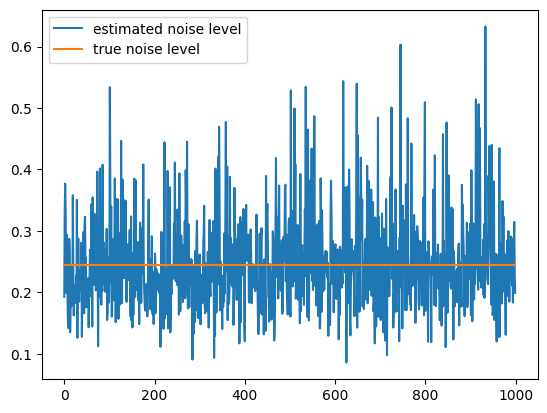

In [137]:
plt.plot(estimated_noise_level, label="estimated noise level")
plt.plot([sigma_noise*1.] * len(estimated_noise_level), label="true noise level")
plt.legend()
plt.show()

(array([  4.,  12.,  19.,  46.,  73.,  97., 117., 110., 133.,  96.,  65.,
         61.,  36.,  29.,  23.,  14.,  18.,  13.,   4.,   8.,   4.,   6.,
          2.,   3.,   4.,   1.,   0.,   0.,   1.,   1.]),
 array([0.08573492, 0.10396515, 0.12219537, 0.14042559, 0.15865581,
        0.17688604, 0.19511626, 0.21334648, 0.2315767 , 0.24980693,
        0.26803715, 0.28626737, 0.3044976 , 0.32272782, 0.34095804,
        0.35918826, 0.37741849, 0.39564871, 0.41387893, 0.43210915,
        0.45033938, 0.4685696 , 0.48679982, 0.50503004, 0.52326027,
        0.54149049, 0.55972071, 0.57795093, 0.59618116, 0.61441138,
        0.6326416 ]),
 <BarContainer object of 30 artists>)

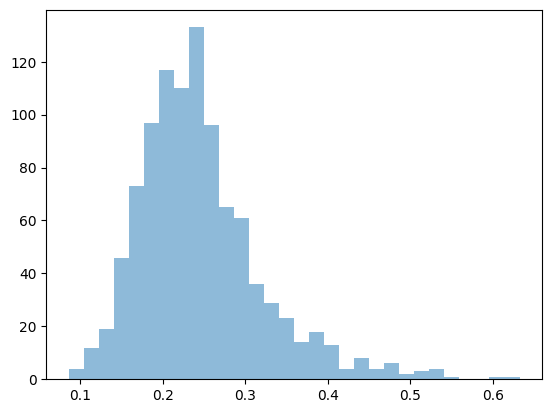

In [138]:
plt.hist(estimated_noise_level, bins=30, alpha=0.5, label="estimated noise level distribution")

In [139]:
np.logspace(-4, 0, 13)

array([1.00000000e-04, 2.15443469e-04, 4.64158883e-04, 1.00000000e-03,
       2.15443469e-03, 4.64158883e-03, 1.00000000e-02, 2.15443469e-02,
       4.64158883e-02, 1.00000000e-01, 2.15443469e-01, 4.64158883e-01,
       1.00000000e+00])

Tuning regularization parameter: 5-fold cross validation (`CV_full`)



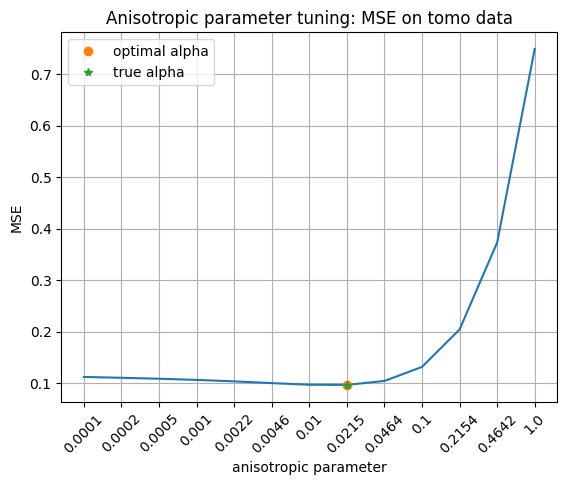

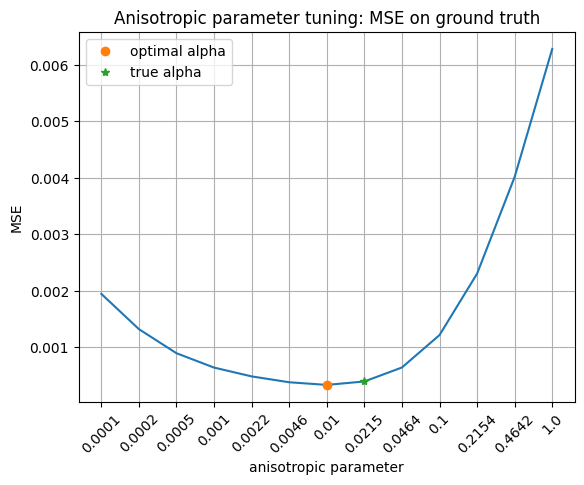

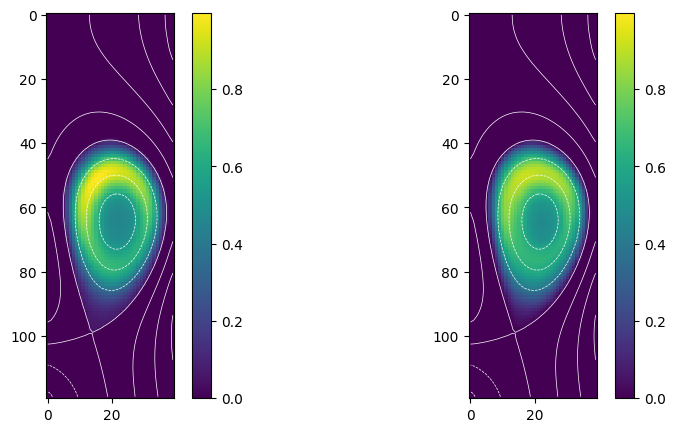

In [215]:
import copy
import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.hyperparameter_tuning as hyper_tune

sxr_samples = copy.deepcopy(test_samples)
samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
psis = np.load(os.path.join(samples_dir, 'psis_coarse.npy'))
alphas = np.load(os.path.join(samples_dir, 'alpha_random_values.npy'))
trim_val = np.load(os.path.join(samples_dir, 'trimming_values.npy'))


idx=12
reconstruction_shape = (120,40)
sigma_err = 0.25

ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
psi = psis[idx, :, :]
trim_val_ = trim_val[idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)

# Define functionals
f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi,
                                                 fwd_matrix=sp.csr_matrix(A_tomo),
                                                sigma_err=sigma_err, reg_fct_type="anisotropic",
                                                alpha=1e-2, plot=False,
                                                seed=idx)
# tune anisotropic parameter
anis_param_data = hyper_tune.anis_param_tuning(f, g, reg_param=1e-1,
                                            tuning_techniques=["CV_full"],
                                            ground_truth=ground_truth,
                                            with_pos_constraint=True, clipping_mask=mask_core,
                                            cv_strategy=["random"],
                                            anis_params=np.logspace(-4, 0, 13), plot=False)

# plot tuning results
plt.plot(anis_param_data['CV_full_random'][1,:])
plt.xticks(np.arange(len(anis_param_data['CV_full_random'][0,:])), labels=np.round(np.logspace(-4, 0, 13), 4), rotation=45)
argmin_algo = np.argmin(anis_param_data['CV_full_random'][1,:])
plt.plot(argmin_algo, anis_param_data['CV_full_random'][1,:][argmin_algo], 'o', label="optimal alpha")
true_alpha_idx=np.argmin(np.abs(np.logspace(-4, 0, 13)- alphas[idx]))
plt.plot(true_alpha_idx, anis_param_data['CV_full_random'][1,:][true_alpha_idx], '*', label="true alpha")
plt.xlabel("anisotropic parameter")
plt.ylabel("MSE")
plt.title("Anisotropic parameter tuning: MSE on tomo data")
plt.grid()
plt.legend()
plt.show()

plt.plot(anis_param_data["CV_full_random"][2,:])
plt.xticks(np.arange(len(anis_param_data['CV_full_random'][0,:])), labels=np.round(np.logspace(-4, 0, 13), 4), rotation=45)
argmin = np.argmin(anis_param_data['CV_full_random'][2,:])
plt.plot(argmin, anis_param_data['CV_full_random'][2,:][argmin], 'o', label="optimal alpha")
true_alpha_idx=np.argmin(np.abs(np.logspace(-4, 0, 13)- alphas[idx]))
plt.plot(true_alpha_idx, anis_param_data['CV_full_random'][2,:][true_alpha_idx], '*', label="true alpha")
plt.xlabel("anisotropic parameter")
plt.ylabel("MSE")
plt.title("Anisotropic parameter tuning: MSE on ground truth")
plt.grid()
plt.legend()
plt.show()

# compute MAP with estimated alpha
reg_param = 1e-1
alpha=anis_param_data['CV_full_random'][0,:][argmin_algo]
# Define functionals
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)
f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=sp.csr_matrix(A_tomo),
                                                        sigma_err=0.25, reg_fct_type="anisotropic",
                                                        alpha=alpha, plot=False,
                                                        seed=idx)
im_MAP = bcomp.compute_MAP(f, g, reg_param, with_pos_constraint=True, clipping_mask=mask_core, show_progress=False)



vmax=np.max([ground_truth.max(), im_MAP.max()])
fig, ax= plt.subplots(1, 2, figsize=(10, 5))
im=ax[0].imshow(ground_truth, vmax=vmax)
plt.colorbar(im,ax=ax[0])
ax[0].contour(psi, colors='w', linewidths=0.5)
im=ax[1].imshow(im_MAP, vmax=vmax)
plt.colorbar(im,ax=ax[1])
ax[1].contour(psi, colors='w', linewidths=0.5)

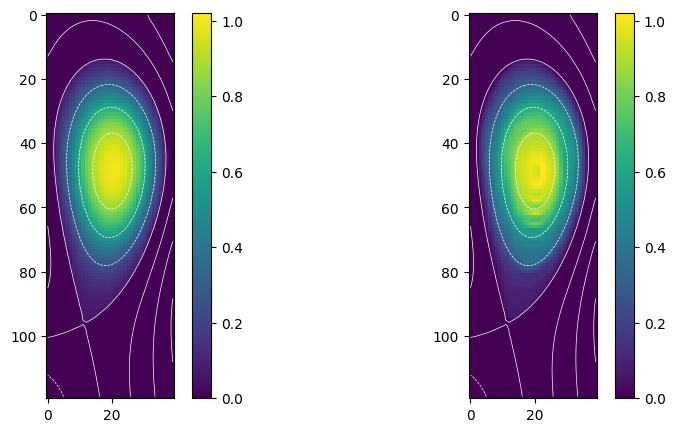

In [212]:
idx=11

ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
psi = psis[idx, :, :]
trim_val_ = trim_val[idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)

mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)
f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=sp.csr_matrix(A_tomo),
                                                        sigma_err=0.25, reg_fct_type="anisotropic",
                                                        alpha=5e-3, plot=False,
                                                        seed=idx)
im_MAP = bcomp.compute_MAP(f, g, reg_param, with_pos_constraint=True, clipping_mask=mask_core, show_progress=False)



vmax=np.max([ground_truth.max(), im_MAP.max()])
fig, ax= plt.subplots(1, 2, figsize=(10, 5))
im=ax[0].imshow(ground_truth, vmax=vmax)
plt.colorbar(im,ax=ax[0])
ax[0].contour(psi, colors='w', linewidths=0.5)
im=ax[1].imshow(im_MAP, vmax=vmax)
plt.colorbar(im,ax=ax[1])
ax[1].contour(psi, colors='w', linewidths=0.5)

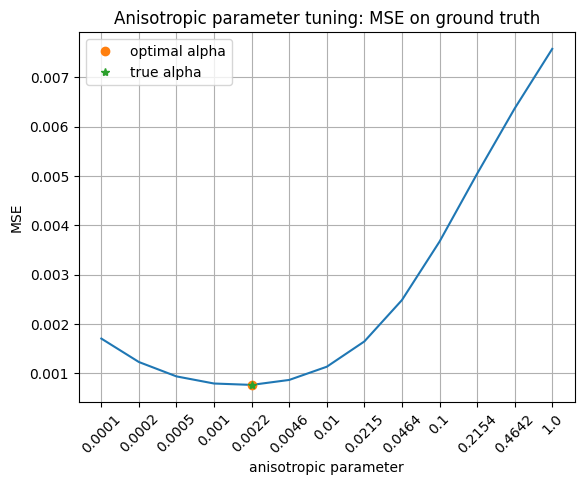

In [197]:
plt.plot(anis_param_data["CV_full_random"][2,:])
plt.xticks(np.arange(len(anis_param_data['CV_full_random'][0,:])), labels=np.round(np.logspace(-4, 0, 13), 4), rotation=45)
argmin = np.argmin(anis_param_data['CV_full_random'][2,:])
plt.plot(argmin, anis_param_data['CV_full_random'][2,:][argmin], 'o', label="optimal alpha")
true_alpha_idx=np.argmin(np.abs(np.logspace(-4, 0, 13)- alphas[idx]))
plt.plot(true_alpha_idx, anis_param_data['CV_full_random'][2,:][true_alpha_idx], '*', label="true alpha")
plt.xlabel("anisotropic parameter")
plt.ylabel("MSE")
plt.title("Anisotropic parameter tuning: MSE on ground truth")
plt.grid()
plt.legend()
plt.show()

In [145]:
anis_param_data['CV_full_random'].shape

(4, 13)

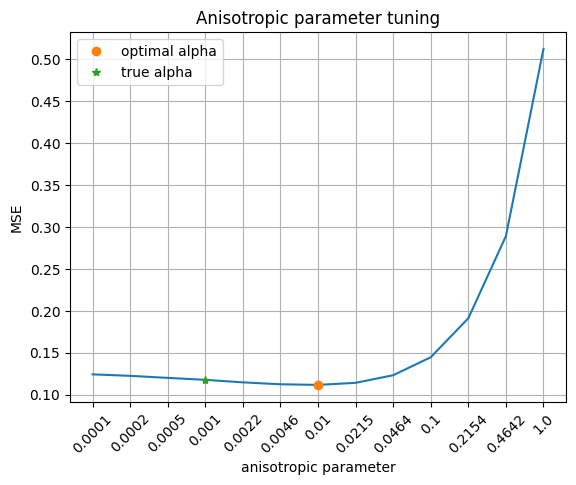

In [ ]:
plt.plot(anis_param_data['CV_full_random'][1,:])
plt.xticks(np.arange(len(anis_param_data['CV_full_random'][0,:])), labels=np.round(np.logspace(-4, 0, 13), 4), rotation=45)
argmin = np.argmin(anis_param_data['CV_full_random'][1,:])
plt.plot(argmin, anis_param_data['CV_full_random'][1,:][argmin], 'o', label="optimal alpha")
true_alpha_idx=np.argmin(np.abs(np.logspace(-4, 0, 13)- alphas[idx]))
plt.plot(true_alpha_idx, anis_param_data['CV_full_random'][1,:][true_alpha_idx], '*', label="true alpha")
plt.xlabel("anisotropic parameter")
plt.ylabel("MSE")
plt.title("Anisotropic parameter tuning")
plt.grid()
plt.legend()
plt.show()


reg_param = 1e-1
alpha=
# Define functionals
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)
f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=sp.csr_matrix(A_tomo),
                                                        sigma_err=0.25, reg_fct_type="anisotropic",
                                                        alpha=alpha, plot=False,
                                                        seed=idx)
im_MAP = bcomp.compute_MAP(f, g, reg_param, with_pos_constraint=True, clipping_mask=mask_core, show_progress=False)



vmax=np.max([ground_truth.max(), im_MAP.max()])
fig, ax= plt.subplots(1, 2, figsize=(10, 5))
im=ax[0].imshow(ground_truth, vmax=vmax)
plt.colorbar(im,ax=ax[0])
ax[0].contour(psi, colors='w', linewidths=0.5)
im=ax[1].imshow(im_MAP, vmax=vmax)
plt.colorbar(im,ax=ax[1])
ax[1].contour(psi, colors='w', linewidths=0.5)

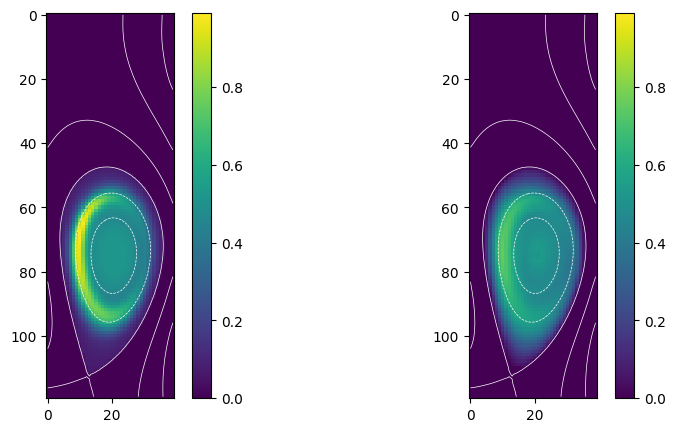

In [ ]:
ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
psi = psis[idx, :, :]
alpha = alphas[idx]
trim_val_ = trim_val[idx, :]


In [154]:
alphas[idx]

np.float64(0.0012876710707433279)

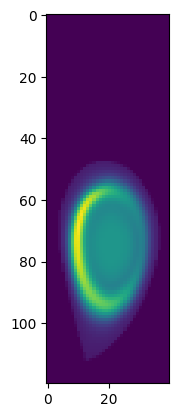

In [155]:
plt.imshow(ground_truth)